
# Airbnb Price Prediction using Multiple Linear Regression (MLR)

## Improved Machine Learning Project

This project predicts Airbnb prices using Multiple Linear Regression (MLR).

### Improvements Added
- Better feature selection
- Outlier removal
- Log transformation
- Proper EDA
- Residual analysis
- Feature importance analysis

### Dataset
Download:
https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

Keep the file name as:
`AB_NYC_2019.csv`


In [46]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Step 1: Load Dataset

In [47]:

df = pd.read_csv("AB_NYC_2019.csv")

df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Step 2: Select Important Features

In [48]:

df = df[[
    'neighbourhood_group',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'price'
]]

# Remove missing values
df = df.dropna()

# Remove extreme price outliers
df = df[df['price'] < 500]

df.head()


,neighbourhood_group,room_type,minimum_nights,number_of_reviews,reviews_per_month,availability_365,price
0,Brooklyn,Private room,1,9,0.21,365,149
1,Manhattan,Entire home/apt,1,45,0.38,355,225
3,Brooklyn,Entire home/apt,1,270,4.64,194,89
4,Manhattan,Entire home/apt,10,9,0.10,0,80
5,Manhattan,Entire home/apt,3,74,0.59,129,200


## Step 3: Exploratory Data Analysis

In [49]:

print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nPrice Statistics")
print(df['price'].describe())


Dataset Shape: (38107, 7)

Missing Values
neighbourhood_group    0
room_type              0
minimum_nights         0
number_of_reviews      0
reviews_per_month      0
availability_365       0
price                  0
dtype: int64

Price Statistics
count    38107.000000
mean       126.938988
std         81.859058
min          0.000000
25%         67.000000
50%        100.000000
75%        160.500000
max        499.000000
Name: price, dtype: float64


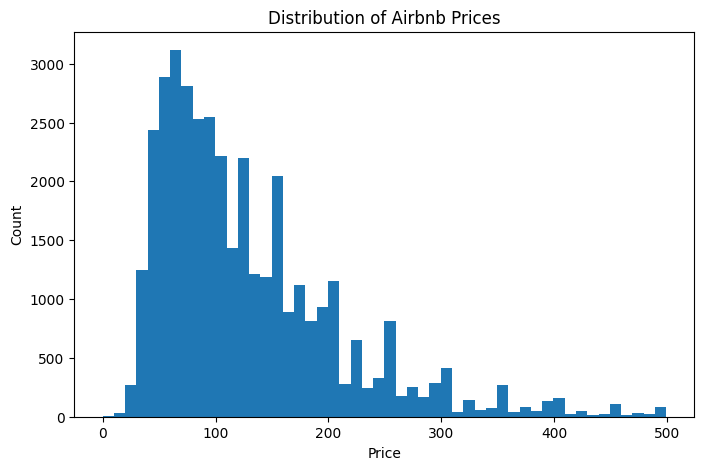

In [50]:

# Price distribution

plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=50)

plt.xlabel("Price")
plt.ylabel("Count")

plt.title("Distribution of Airbnb Prices")

plt.show()


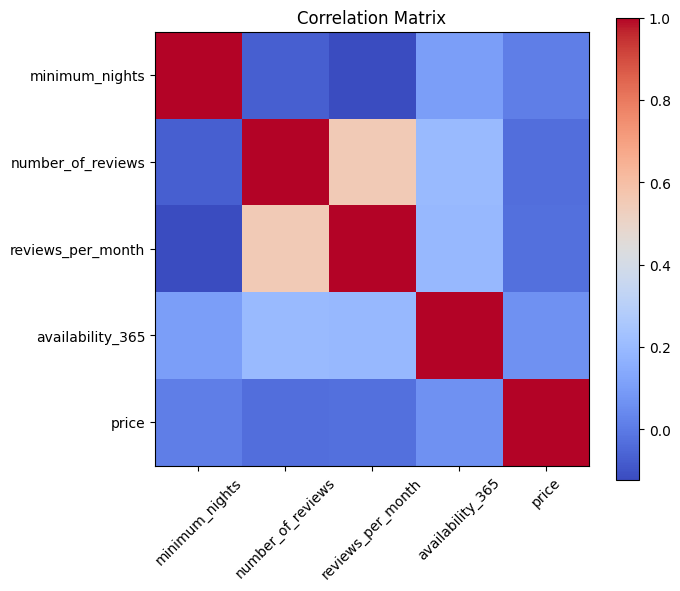

In [51]:

# Correlation matrix

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()


## Step 4: Feature Encoding

In [52]:

encoder = LabelEncoder()

df['room_type'] = encoder.fit_transform(df['room_type'])

df['neighbourhood_group'] = encoder.fit_transform(df['neighbourhood_group'])

df.head()


,neighbourhood_group,room_type,minimum_nights,number_of_reviews,reviews_per_month,availability_365,price
0,1,1,1,9,0.21,365,149
1,2,0,1,45,0.38,355,225
3,1,0,1,270,4.64,194,89
4,2,0,10,9,0.10,0,80
5,2,0,3,74,0.59,129,200


## Step 5: Features and Target

In [53]:
X = df.drop('price', axis=1)

# Log transformation improves regression performance
# Adding a small constant (1e-6) to handle zero values in 'price' before log transformation
y = np.log(df['price'] + 1e-6)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (38107, 6)
Target Shape: (38107,)


## Step 6: Train Test Split

In [54]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (30485, 6)
Testing Data: (7622, 6)


## Step 7: Feature Scaling

In [55]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


## Step 8: Multiple Linear Regression Model

In [56]:

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


In [57]:

# Model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients


,Feature,Coefficient
0,neighbourhood_group,0.036880
1,room_type,-0.410183
2,minimum_nights,-0.028085
3,number_of_reviews,-0.007346
4,reviews_per_month,-0.015334
5,availability_365,0.050911


## Step 9: Predictions

In [58]:

y_pred = model.predict(X_test)

# Convert log values back to normal prices
actual_prices = np.exp(y_test)
predicted_prices = np.exp(y_pred)

results = pd.DataFrame({
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

results.head(10)


,Actual Price,Predicted Price
0,49.000001,67.959252
1,196.000001,171.603850
2,95.000001,162.010852
3,199.000001,175.038597
4,50.000001,68.185775
5,249.000001,152.461762
6,180.000001,142.634140
7,65.000001,72.842795
8,250.000001,151.268564
9,80.000001,71.993263


## Step 10: Model Evaluation

In [59]:

mae = mean_absolute_error(actual_prices, predicted_prices)

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

r2 = r2_score(actual_prices, predicted_prices)

print("Mean Absolute Error (MAE):", round(mae, 2))

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

print("R2 Score:", round(r2, 4))


Mean Absolute Error (MAE): 44.59
Root Mean Squared Error (RMSE): 68.89
R2 Score: 0.3201


## Step 11: Actual vs Predicted Graph

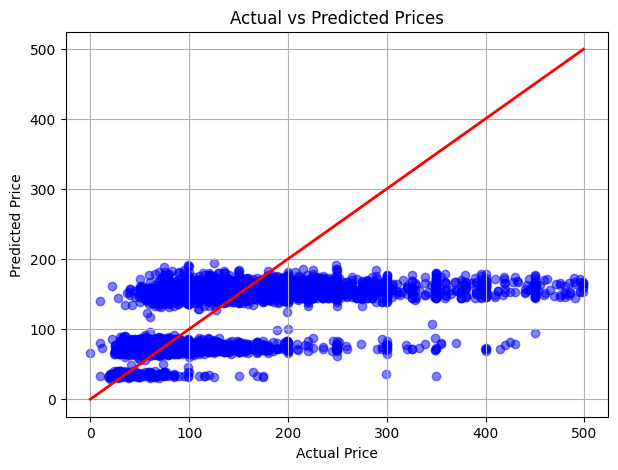

In [60]:

plt.figure(figsize=(7,5))

plt.scatter(
    actual_prices,
    predicted_prices,
    color='blue',
    alpha=0.5
)

plt.plot(
    [actual_prices.min(), actual_prices.max()],
    [actual_prices.min(), actual_prices.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.grid(True)

plt.show()


## Step 12: Residual Analysis

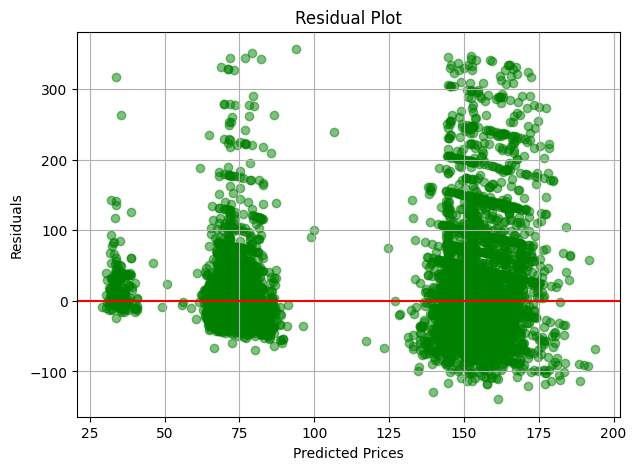

In [61]:

residuals = actual_prices - predicted_prices

plt.figure(figsize=(7,5))

plt.scatter(
    predicted_prices,
    residuals,
    color='green',
    alpha=0.5
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


## Step 13: Feature Importance

In [62]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance


,Feature,Importance
5,availability_365,0.050911
0,neighbourhood_group,0.036880
3,number_of_reviews,-0.007346
4,reviews_per_month,-0.015334
2,minimum_nights,-0.028085
1,room_type,-0.410183


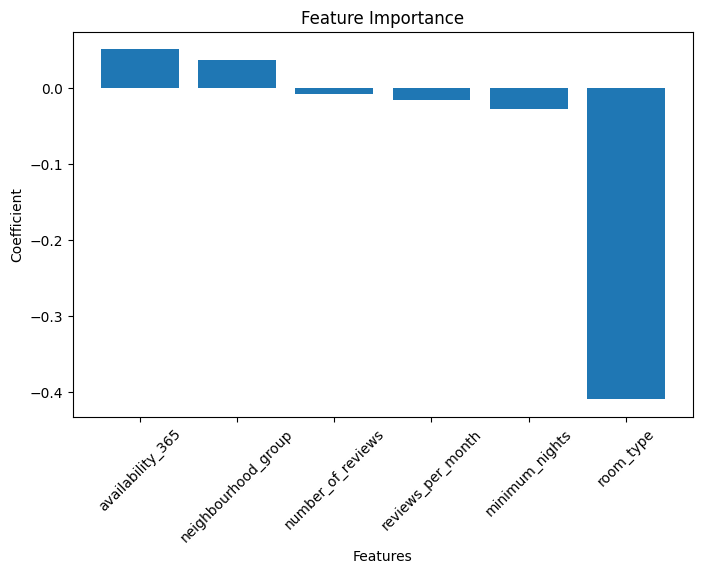

In [63]:

plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.title("Feature Importance")

plt.show()



# Conclusion

- Multiple Linear Regression was successfully implemented.
- EDA and preprocessing improved the model.
- Log transformation reduced prediction errors.
- The model predicts Airbnb prices using multiple features.
- Residual analysis and feature importance were studied.

## Future Improvements
- Add more amenities
- Use Ridge/Lasso Regression
- Try Random Forest and XGBoost


In [64]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [66]:
r2 = r2_score(y_test, rf_pred)

print(r2)

actual_prices = np.exp(y_test)
predicted_prices = np.exp(rf_pred)

results = pd.DataFrame({
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

results

0.44344943103535384


,Actual Price,Predicted Price
0,49.000001,63.679379
1,196.000001,268.599447
2,95.000001,131.122419
3,199.000001,237.456262
4,50.000001,45.661064
...,...,...
7617,115.000001,116.224795
7618,450.000001,173.954234
7619,50.000001,43.181710
7620,129.000001,147.091135
